# Notebook 3 — Feature Engineering & Split Train/Validation

## Catalogue complet des features

| Famille | Features | N | Bibliothèque source |
|---------|----------|---|---------------------|
| Fractions brutes | pct_A, pct_T, pct_C, pct_G, pct_GC | 5 | data_processing.py |
| Qualité brute | avg_quality, num_reads, avg_read_length | 3 | data_processing.py |
| Ratios biologiques | gc_skew, at_skew, purine_pyrimidine_ratio, nucleotide_entropy | 4 | feature_engineering.py |
| **K-mers (k=3)** | kmer_AAA … kmer_TTT | **64** | feature_engineering.py |
| **Dinucléotides relatifs** | di_AA … di_TT (rho) | **16** | feature_engineering.py |
| **Qualité différenciée** | pct_bases_q20, pct_bases_q30 | **2** | feature_engineering.py |
| **TOTAL** | | **94** | |

### Justification des nouvelles features

**K-mers** : les fréquences de trinucléotides capturent le contexte local de la séquence.  
Sans assignation taxonomique, c'est la représentation la plus informative pour distinguer  
les sites corporels depuis des séquences 16S rRNA brutes.  
*(Woloszynek et al., 2019, PLoS Comput Biol ; MicroPheno — Reiman et al., 2018)*

**Dinucléotides relatifs (rho)** : rho(XY) = f(XY) / (f(X)·f(Y)).  
Les déviations par rapport à l'indépendance sont une signature génomique conservée  
par espèce bactérienne, distincte par site corporel.  
*(Karlin & Burge, 1995, Trends Genet)*

**Qualité Q20/Q30** : la fraction de bases à haute qualité Phred peut varier  
selon le site corporel (densité microbienne, inhibiteurs PCR présents dans certains prélèvements).

---

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from Bio import SeqIO
from tqdm import tqdm
from datetime import datetime
import os
import sys
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Imports standards OK')

✅ Imports standards OK


In [2]:
sys.path.append('../src')
from feature_engineering import (
    build_features,
    split_by_subject,
    compute_kmer_frequencies_fast,
    compute_relative_dinucleotide_frequencies_fast,
    extract_fastq_features,
)

print('✅ Fonctions importées depuis src/feature_engineering.py')

✅ Fonctions importées depuis src/feature_engineering.py


## 1. Configuration des chemins

In [3]:
PROCESSED_PATH = Path('../data/processed')
FIGURES_PATH   = Path('../results/figures')
TRAIN_MGB_PATH = Path('../data/raw/TrainFiles')
TEST_MGB_PATH = Path('../data/raw/TestFiles')

print(f'📁 Raw       : {TRAIN_MGB_PATH.absolute()}')
print(f'📁 Raw       : {TEST_MGB_PATH.absolute()}')
print(f'📁 Processed : {PROCESSED_PATH.absolute()}')
print(f'📁 Figures   : {FIGURES_PATH.absolute()}')

📁 Raw       : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/raw/TrainFiles
📁 Raw       : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/raw/TestFiles
📁 Processed : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/processed
📁 Figures   : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../results/figures


## 2. Chargement des données (output Notebook 2)

In [4]:
df_train_fastq = pd.read_csv(PROCESSED_PATH / 'train_fastq_features.csv')
df_train_fastq

,filename,SampleType,SubjectID,SampleID,num_reads,avg_read_length,avg_quality,pct_A,pct_T,pct_C,pct_G,pct_GC
0,ID_LETPJN.mgb,Stool,Subject_BCUNIB,Sample_AFTIWE,21599,400.0,36.898560,0.279865,0.191989,0.222465,0.305681,0.528146
1,ID_NTDGIW.mgb,Stool,Subject_UDAXIH,Sample_JQJVNK,20295,400.0,36.920443,0.268719,0.195539,0.221133,0.314609,0.535742
2,ID_ZISBMF.mgb,Nasal,Subject_VRKADI,Sample_YJWGWW,16449,400.0,36.368796,0.249779,0.198518,0.221118,0.330586,0.551703
3,ID_MDCVXU.mgb,Nasal,Subject_HIFZWD,Sample_VKEHZP,36965,400.0,36.151231,0.253585,0.201211,0.221141,0.324064,0.545204
4,ID_SWAMNY.mgb,Stool,Subject_VGLNCV,Sample_NTDTEQ,40236,400.0,36.416148,0.267547,0.195356,0.224603,0.312494,0.537097
...,...,...,...,...,...,...,...,...,...,...,...,...
2896,ID_YBMPZU.mgb,Mouth,Subject_NHOSIZ,Sample_RAZQOY,562248,124.5,33.208567,0.210990,0.273035,0.265105,0.250870,0.515974
2897,ID_KIVZDA.mgb,Mouth,Subject_OZRDBU,Sample_GKJHPV,613378,124.5,33.307892,0.209759,0.277077,0.263726,0.249438,0.513164
2898,ID_IDGAEG.mgb,Skin,Subject_IBWNAQ,Sample_GHULTX,362360,124.5,33.029108,0.214296,0.277877,0.260209,0.247619,0.507828
2899,ID_TGSMCA.mgb,Skin,Subject_MBPHGO,Sample_DBDVLO,128692,124.5,33.175355,0.196824,0.264438,0.279915,0.258823,0.538738


In [5]:
print(f'Échantillons   : {len(df_train_fastq)}')
print(f'Sujets uniques : {df_train_fastq["SubjectID"].nunique()}')
print(f'\nDistribution SampleType :')
print(df_train_fastq['SampleType'].value_counts())

Échantillons   : 2901
Sujets uniques : 66

Distribution SampleType :
SampleType
Stool    811
Skin     787
Nasal    710
Mouth    593
Name: count, dtype: int64


## 3. Features de base (depuis pct_A/T/C/G — pas besoin des FASTQ)

Ces features sont construites directement depuis `train_fastq_features.csv`.

In [6]:
base_features = build_features(df_train_fastq)
print(f'\nAperçu :')
base_features.describe().round(4)

✅ 12 features construites :
   Brutes    : pct_A, pct_T, pct_C, pct_G, pct_GC, avg_quality, num_reads, avg_read_length
   Dérivées  : gc_skew, at_skew, purine_pyrimidine_ratio, nucleotide_entropy

Aperçu :


,pct_A,pct_T,pct_C,pct_G,pct_GC,avg_quality,num_reads,avg_read_length,gc_skew,at_skew,purine_pyrimidine_ratio,nucleotide_entropy
count,2901.0000,2901.0000,2901.0000,2901.0000,2901.0000,2901.0000,2.901000e+03,2901.0000,2901.0000,2901.0000,2901.0000,2901.0000
mean,0.2266,0.2311,0.2476,0.2947,0.5423,35.1529,1.616689e+05,268.9452,0.0850,-0.0090,1.1240,1.9791
std,0.0329,0.0360,0.0273,0.0358,0.0176,1.5490,9.257161e+05,137.6109,0.1109,0.1455,0.2723,0.0099
min,0.1690,0.1597,0.2071,0.2313,0.4901,31.5815,1.300000e+01,124.5000,-0.0614,-0.2210,0.8015,1.9505
25%,0.2025,0.1988,0.2216,0.2569,0.5279,33.7406,1.668800e+04,124.5000,-0.0278,-0.1433,0.8443,1.9728
50%,0.2224,0.2057,0.2289,0.3062,0.5412,36.0794,3.096300e+04,400.0000,0.1561,0.0414,1.3506,1.9778
75%,0.2647,0.2668,0.2734,0.3216,0.5572,36.4935,1.182480e+05,400.0000,0.1768,0.1475,1.3782,1.9895
max,0.2803,0.2841,0.2979,0.3638,0.5999,37.2293,3.501304e+07,400.0000,0.2502,0.2333,1.4831,1.9974


## 4. Extraction des features depuis les séquences brutes (FASTQ)

**Approche retenue :** traitement parallèle + NumPy.  
- `extract_fastq_features` charge un fichier, calcule les features et libère les reads immédiatement.  
- `ProcessPoolExecutor` répartit le travail sur tous les cœurs CPU disponibles.  
- Le comptage des k-mers utilise le *stride trick* NumPy + `bincount` (~50× vs Python pur).

In [7]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path
import psutil

_SRC_ABS = str(Path("../src").resolve())


def _worker_fastq(args):
    idx, filename, fastq_dir, src_abs = args
    import sys; sys.path.insert(0, src_abs)
    from feature_engineering import extract_fastq_features
    from pathlib import Path
    fastq_path = Path(fastq_dir) / filename.replace(".mgb", ".fastq")
    return idx, extract_fastq_features(fastq_path)


def run_fastq_pipeline(df, fastq_dir, n_workers, desc):
    """Extrait les features FASTQ en parallèle pour un DataFrame de samples.

    Returns
    -------
    rows_kmer, rows_di, rows_qual, valid_indices
    """
    args_list = [(idx, row["filename"], str(fastq_dir), _SRC_ABS)
                 for idx, row in df.iterrows()]

    rows_kmer, rows_di, rows_qual, valid_indices = [], [], [], []

    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_worker_fastq, a): a[0] for a in args_list}
        for future in tqdm(as_completed(futures), total=len(futures), desc=desc):
            idx, feats = future.result()
            if feats is None:
                continue
            kmer_keys = [k for k in feats if k.startswith("kmer_")]
            di_keys   = [k for k in feats if k.startswith("di_")]
            qual_keys = [k for k in feats if k.startswith("pct_bases_")]
            rows_kmer.append({k: feats[k] for k in kmer_keys})
            rows_di.append(  {k: feats[k] for k in di_keys})
            rows_qual.append({k: feats[k] for k in qual_keys})
            valid_indices.append(idx)

    valid_indices.sort()
    return rows_kmer, rows_di, rows_qual, valid_indices


# Lecture par blocs de 200k reads → pic par worker ≤ 320 MB quelle que soit la taille du fichier
available_gb = psutil.virtual_memory().available / 1e9
N_WORKERS    = max(1, os.cpu_count() - 1)
print(f"Workers : {N_WORKERS}  |  RAM disponible : {available_gb:.1f} GB")
print(f"⏰ Début : {datetime.now().strftime('%H:%M:%S')}")

rows_kmer, rows_di, rows_qual, valid_indices = run_fastq_pipeline(
    df_train_fastq, "../data/raw/TrainFiles", N_WORKERS, "📂 FASTQ train"
)

print(f"⏰ Fin   : {datetime.now().strftime('%H:%M:%S')}")
print(f"\n✅ {len(valid_indices)}/{len(df_train_fastq)} échantillons traités")

Workers : 11  |  RAM disponible : 27.5 GB
⏰ Début : 18:39:24


📂 FASTQ train: 100%|██████████| 2901/2901 [06:32<00:00,  7.40it/s]

⏰ Fin   : 18:45:56

✅ 2901/2901 échantillons traités


In [8]:
df_for_all = df_train_fastq.loc[valid_indices].reset_index(drop=True)

base    = build_features(df_for_all)
kmer_df = pd.DataFrame(rows_kmer)
di_df   = pd.DataFrame(rows_di)
qual_df = pd.DataFrame(rows_qual)

all_features = pd.concat(
    [base.reset_index(drop=True), kmer_df, di_df, qual_df], axis=1
)

print(f'FEATURES TOTALES : {all_features.shape[1]}')
print(f'  Base + dérivées : {base.shape[1]}')
print(f'  K-mers (k=3)    : {kmer_df.shape[1]}')
print(f'  Dinucléotides   : {di_df.shape[1]}')
print(f'  Qualité Q20/Q30 : {qual_df.shape[1]}')

✅ 12 features construites :
   Brutes    : pct_A, pct_T, pct_C, pct_G, pct_GC, avg_quality, num_reads, avg_read_length
   Dérivées  : gc_skew, at_skew, purine_pyrimidine_ratio, nucleotide_entropy
FEATURES TOTALES : 94
  Base + dérivées : 12
  K-mers (k=3)    : 64
  Dinucléotides   : 16
  Qualité Q20/Q30 : 2


## 5. Assemblage du DataFrame final

In [9]:
META_COLS = ['filename', 'SubjectID', 'SampleID', 'SampleType']

df_final = pd.concat([
    df_for_all[META_COLS].reset_index(drop=True),
    all_features.reset_index(drop=True)
], axis=1)

feature_cols = [c for c in df_final.columns if c not in META_COLS]

print(f'Features totales : {len(feature_cols)}')
df_final

Features totales : 94


,filename,SubjectID,SampleID,SampleType,pct_A,pct_T,pct_C,pct_G,pct_GC,avg_quality,...,di_GA,di_GC,di_GG,di_GT,di_TA,di_TC,di_TG,di_TT,pct_bases_q20,pct_bases_q30
0,ID_LETPJN.mgb,Subject_BCUNIB,Sample_AFTIWE,Stool,0.279865,0.191989,0.222465,0.305681,0.528146,36.898560,...,1.043818,1.105171,1.013525,0.819225,1.051674,0.715299,1.155200,0.968834,0.986480,0.939628
1,ID_NTDGIW.mgb,Subject_UDAXIH,Sample_JQJVNK,Stool,0.268719,0.195539,0.221133,0.314609,0.535742,36.920443,...,1.113244,0.944255,1.056214,0.818216,0.904704,0.879125,1.130048,1.074456,0.991549,0.959148
2,ID_ZISBMF.mgb,Subject_VRKADI,Sample_YJWGWW,Nasal,0.249779,0.198518,0.221118,0.330586,0.551703,36.368796,...,1.080970,1.021996,1.024300,0.824829,0.918339,0.738394,1.167690,1.129776,0.988002,0.941185
3,ID_MDCVXU.mgb,Subject_HIFZWD,Sample_VKEHZP,Nasal,0.253585,0.201211,0.221141,0.324064,0.545204,36.151231,...,1.032774,1.080687,1.028387,0.833520,1.047952,0.646962,1.170871,1.027068,0.985606,0.934698
4,ID_SWAMNY.mgb,Subject_VGLNCV,Sample_NTDTEQ,Stool,0.267547,0.195356,0.224603,0.312494,0.537097,36.416148,...,1.016881,1.077581,1.081743,0.784323,1.048065,0.721181,1.125611,1.016085,0.983362,0.926197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2896,ID_YBMPZU.mgb,Subject_NHOSIZ,Sample_RAZQOY,Mouth,0.210990,0.273035,0.265105,0.250870,0.515974,33.208567,...,0.831518,1.113357,0.983449,1.032285,1.034431,0.996623,0.860956,1.090024,0.945048,0.862100
2897,ID_KIVZDA.mgb,Subject_OZRDBU,Sample_GKJHPV,Mouth,0.209759,0.277077,0.263726,0.249438,0.513164,33.307892,...,0.831382,1.100992,1.009361,1.022929,1.031824,1.014971,0.840659,1.085970,0.947251,0.888500
2898,ID_IDGAEG.mgb,Subject_IBWNAQ,Sample_GHULTX,Skin,0.214296,0.277877,0.260209,0.247619,0.507828,33.029108,...,0.883954,1.081045,1.001287,1.001285,1.035453,0.988205,0.922913,1.043269,0.939448,0.857117
2899,ID_TGSMCA.mgb,Subject_MBPHGO,Sample_DBDVLO,Skin,0.196824,0.264438,0.279915,0.258823,0.538738,33.175355,...,0.844374,1.104945,0.971157,1.043576,1.009707,1.034226,0.778033,1.128585,0.956933,0.907827


## 6. Analyse exploratoire des nouvelles features

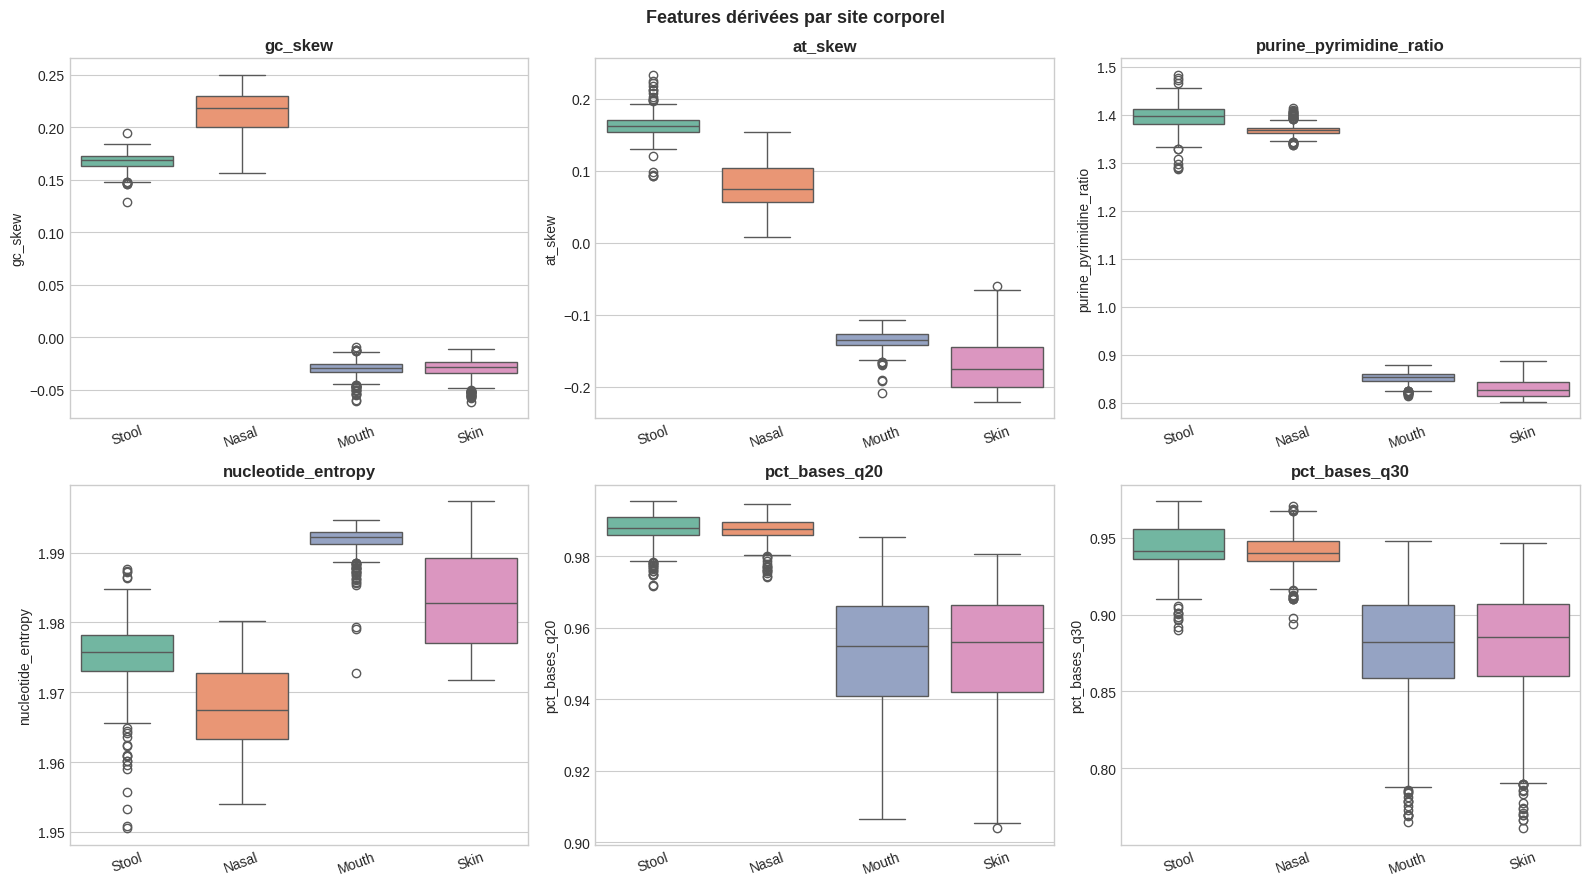

✅ 03_derived_features_by_sampletype.png


In [10]:
# Ratios biologiques par site corporel
derived_features = ['gc_skew', 'at_skew', 'purine_pyrimidine_ratio',
                    'nucleotide_entropy', 'pct_bases_q20', 'pct_bases_q30']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, derived_features):
    sns.boxplot(data=df_final, x='SampleType', y=feat, ax=ax, palette='Set2')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Features dérivées par site corporel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_derived_features_by_sampletype.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 03_derived_features_by_sampletype.png')

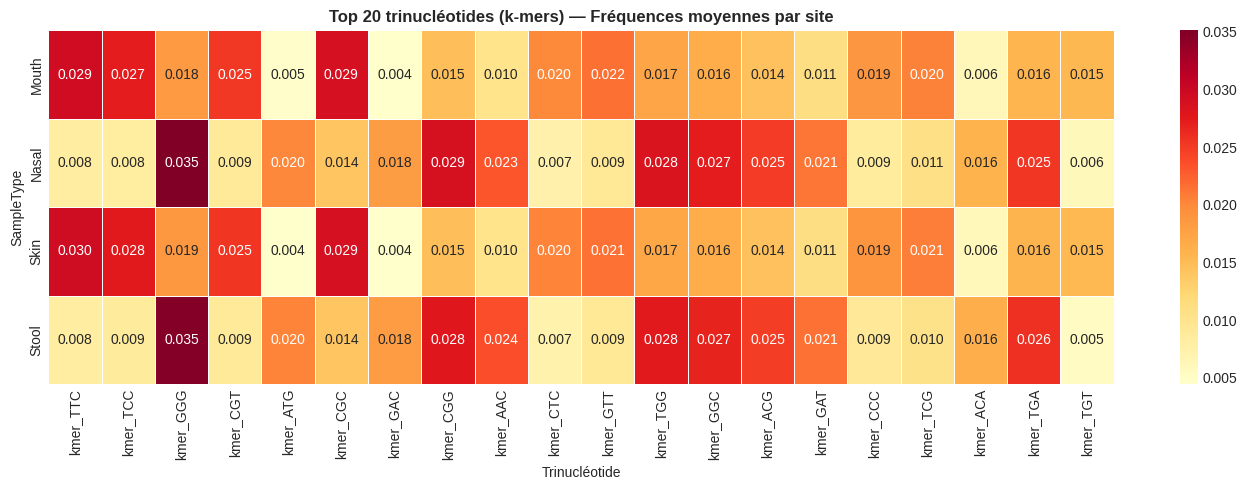

✅ 03_top20_kmers_heatmap.png


In [11]:
# Heatmap des k-mers les plus discriminants
kmer_cols = [c for c in df_final.columns if c.startswith('kmer_')]

# Moyenne par SampleType
kmer_by_site = df_final.groupby('SampleType')[kmer_cols].mean()

# Top 20 k-mers avec la variance inter-sites la plus élevée

inter_site_var = kmer_by_site.var(axis=0)
top20_kmers = inter_site_var.nlargest(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    kmer_by_site[top20_kmers],
    annot=True, fmt='.3f', cmap='YlOrRd',
    ax=ax, linewidths=0.5
)
ax.set_title('Top 20 trinucléotides (k-mers) — Fréquences moyennes par site',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Trinucléotide')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_top20_kmers_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 03_top20_kmers_heatmap.png')

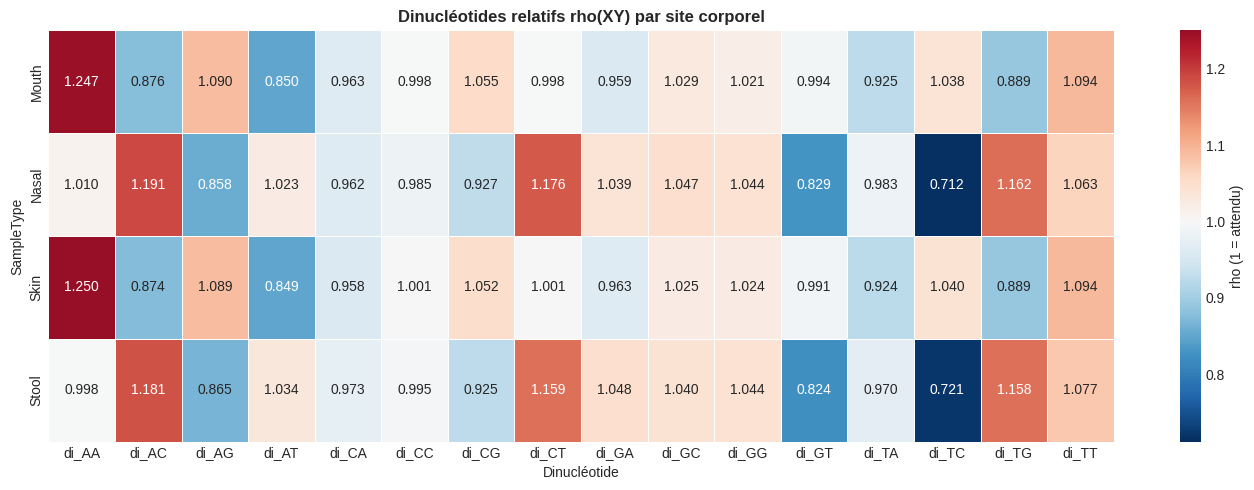

✅ 03_dinucleotides_relatifs_heatmap.png


In [12]:
# Heatmap dinucléotides relatifs (rho)
di_cols = [c for c in df_final.columns if c.startswith('di_')]
di_by_site = df_final.groupby('SampleType')[di_cols].mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    di_by_site,
    annot=True, fmt='.3f', cmap='RdBu_r', center=1.0,
    ax=ax, linewidths=0.5,
    cbar_kws={'label': 'rho (1 = attendu)'}
)
ax.set_title('Dinucléotides relatifs rho(XY) par site corporel',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Dinucléotide')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_dinucleotides_relatifs_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 03_dinucleotides_relatifs_heatmap.png')

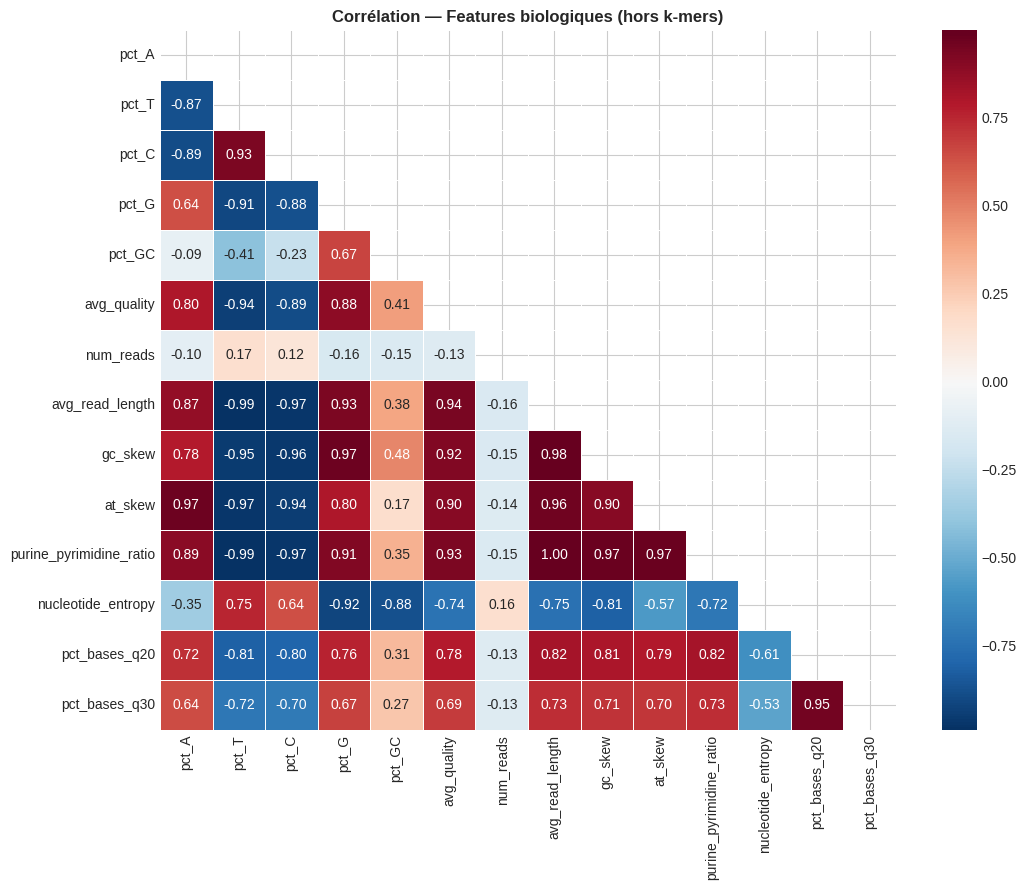

In [13]:
# Matrice de corrélation — features non-kmer (12 features)
non_kmer_features = [c for c in feature_cols if not c.startswith('kmer_') and not c.startswith('di_')]
corr = df_final[non_kmer_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Corrélation — Features biologiques (hors k-mers)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Split Train / Validation sans data leakage

In [14]:
# Analyse sujets multi-sites
subject_types = df_final.groupby('SubjectID')['SampleType'].nunique()
mono  = (subject_types == 1).sum()
multi = (subject_types > 1).sum()
print(f'Mono-site  : {mono} ({100*mono/len(subject_types):.1f}%)')
print(f'Multi-site : {multi} ({100*multi/len(subject_types):.1f}%)')
print(f'→ {multi} sujets créeraient du data leakage avec un split aléatoire.')

Mono-site  : 1 (1.5%)
Multi-site : 65 (98.5%)
→ 65 sujets créeraient du data leakage avec un split aléatoire.


In [15]:
train_df, val_df = split_by_subject(
    df_final, subject_col='SubjectID', target_col='SampleType',
    val_size=0.2, random_state=42
)

SPLIT TRAIN / VALIDATION (par SubjectID)
  Sujets train :  54  |  Échantillons : 2463
  Sujets val   :  12  |  Échantillons :  438

  Distribution SampleType — TRAIN :
    Stool      :  713 (28.9%)
    Skin       :  650 (26.4%)
    Nasal      :  607 (24.6%)
    Mouth      :  493 (20.0%)
  Distribution SampleType — VAL :
    Skin       :  137 (31.3%)
    Nasal      :  103 (23.5%)
    Mouth      :  100 (22.8%)
    Stool      :   98 (22.4%)
✅ Vérification anti-leakage : OK


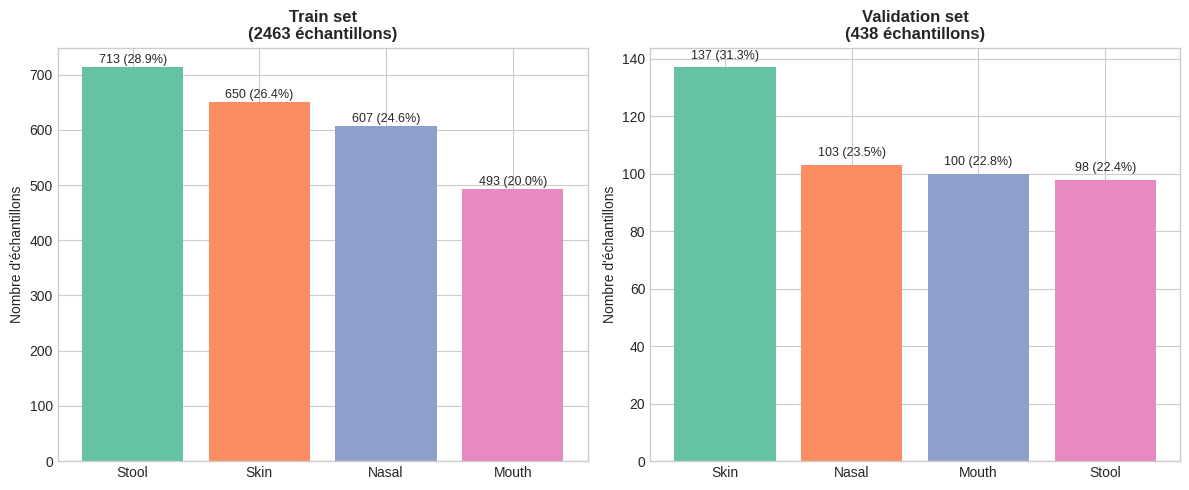

In [16]:
# Visualisation distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes, [train_df, val_df], ['Train set', 'Validation set']):
    counts = data['SampleType'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'{title}\n({len(data)} échantillons)', fontweight='bold')
    ax.set_ylabel("Nombre d'échantillons")
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{count} ({100*count/len(data):.1f}%)',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_train_val_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sauvegarde

In [17]:
train_df.to_csv(PROCESSED_PATH / 'train_engineered.csv', index=False)
val_df.to_csv(PROCESSED_PATH / 'val_engineered.csv', index=False)
pd.Series(feature_cols, name='feature').to_csv(
    PROCESSED_PATH / 'feature_cols.csv', index=False
)

print('✅ Fichiers sauvegardés :')
print(f'   train_engineered.csv → {train_df.shape}')
print(f'   val_engineered.csv   → {val_df.shape}')
print(f'   feature_cols.csv     → {len(feature_cols)} features')
print('\n→ Exécuter la section 9 pour générer test_engineered.csv')

✅ Fichiers sauvegardés :
   train_engineered.csv → (2463, 98)
   val_engineered.csv   → (438, 98)
   feature_cols.csv     → 94 features

→ Exécuter la section 9 pour générer test_engineered.csv


## 9. Feature engineering des données de test

Même pipeline que pour le train, sans les colonnes de label  
(`SampleType`, `SubjectID`, `SampleID` absentes dans le jeu de test).

In [18]:
df_test_fastq = pd.read_csv(PROCESSED_PATH / 'test_fastq_features.csv')

print(f'Shape : {df_test_fastq.shape}')
print(f'Colonnes : {df_test_fastq.columns.tolist()}')
df_test_fastq.head(3)

Shape : (1068, 9)
Colonnes : ['filename', 'num_reads', 'avg_read_length', 'avg_quality', 'pct_A', 'pct_T', 'pct_C', 'pct_G', 'pct_GC']


,filename,num_reads,avg_read_length,avg_quality,pct_A,pct_T,pct_C,pct_G,pct_GC
0,ID_IXPYEV.mgb,40313,400.0,36.661110,0.219899,0.204140,0.218394,0.357567,0.575961
1,ID_OCJFSP.mgb,401140,124.5,33.838746,0.206577,0.268548,0.270550,0.254325,0.524875
2,ID_HYTXHX.mgb,43900,400.0,36.583156,0.269500,0.186307,0.226752,0.317442,0.544193


In [19]:
print(f"⏰ Début : {datetime.now().strftime('%H:%M:%S')}")

rows_kmer_test, rows_di_test, rows_qual_test, valid_test_idx = run_fastq_pipeline(
    df_test_fastq, "../data/raw/TestFiles", N_WORKERS, "📂 FASTQ test"
)

print(f"⏰ Fin   : {datetime.now().strftime('%H:%M:%S')}")
print(f"\n✅ {len(valid_test_idx)}/{len(df_test_fastq)} échantillons test traités")

⏰ Début : 18:47:10


📂 FASTQ test: 100%|██████████| 1068/1068 [01:37<00:00, 11.00it/s]

⏰ Fin   : 18:48:48

✅ 1068/1068 échantillons test traités


In [20]:
df_test_for_all = df_test_fastq.loc[valid_test_idx].reset_index(drop=True)

base_test    = build_features(df_test_for_all)
kmer_df_test = pd.DataFrame(rows_kmer_test)
di_df_test   = pd.DataFrame(rows_di_test)
qual_df_test = pd.DataFrame(rows_qual_test)

all_features_test = pd.concat(
    [base_test.reset_index(drop=True), kmer_df_test, di_df_test, qual_df_test], axis=1
)

✅ 12 features construites :
   Brutes    : pct_A, pct_T, pct_C, pct_G, pct_GC, avg_quality, num_reads, avg_read_length
   Dérivées  : gc_skew, at_skew, purine_pyrimidine_ratio, nucleotide_entropy


In [21]:
# Assemblage du DataFrame test final (sans labels)
df_test_final = pd.concat([
    df_test_for_all[['filename']].reset_index(drop=True),
    all_features_test.reset_index(drop=True)
], axis=1)

print(f'DataFrame test : {df_test_final.shape}')
print(f'Features       : {df_test_final.shape[1] - 1}  (hors filename)')

# Vérification cohérence avec le train
test_feature_cols = [c for c in df_test_final.columns if c != 'filename']
missing = set(feature_cols) - set(test_feature_cols)
extra   = set(test_feature_cols) - set(feature_cols)
if missing:
    print(f'⚠️  Features manquantes vs train : {missing}')
elif extra:
    print(f'⚠️  Features en trop vs train    : {extra}')
else:
    print('✅ Jeu de features identique au train')

df_test_final.head(2)

DataFrame test : (1068, 95)
Features       : 94  (hors filename)
✅ Jeu de features identique au train


,filename,pct_A,pct_T,pct_C,pct_G,pct_GC,avg_quality,num_reads,avg_read_length,gc_skew,...,di_GA,di_GC,di_GG,di_GT,di_TA,di_TC,di_TG,di_TT,pct_bases_q20,pct_bases_q30
0,ID_IXPYEV.mgb,0.219899,0.204140,0.218394,0.357567,0.575961,36.661110,40313,400.0,0.241636,...,1.105929,0.938539,1.051029,0.964363,0.812024,1.089224,0.896616,1.106900,0.964575,0.904669
1,ID_OCJFSP.mgb,0.206577,0.268548,0.270550,0.254325,0.524875,33.838746,401140,124.5,-0.030913,...,1.004040,1.058081,1.046920,0.867849,0.976400,0.691548,1.247369,0.959653,0.985461,0.933459


In [22]:
df_test_final.to_csv(PROCESSED_PATH / 'test_engineered.csv', index=False)

print('✅ test_engineered.csv sauvegardé :')
print(f'   Shape    : {df_test_final.shape}')
print(f'   Features : {len(test_feature_cols)}')
print(f'\n→ Prêt pour la prédiction (Notebook 4 / Modeling)')

✅ test_engineered.csv sauvegardé :
   Shape    : (1068, 95)
   Features : 94

→ Prêt pour la prédiction (Notebook 4 / Modeling)


## Résumé du Notebook 3

| Famille | Features | N | Justification |
|---------|----------|---|---------------|
| Fractions brutes | pct_A/T/C/G/GC | 5 | Composition nucléotidique directe |
| Qualité brute | avg_quality, num_reads, avg_read_length | 3 | Profondeur et fiabilité |
| Ratios biologiques | gc_skew, at_skew, R/Y, entropie | 4 | Lobry 1996 ; Forsdyke 2000 |
| K-mers (k=3) | kmer_AAA…TTT | 64 | Woloszynek 2019 ; MicroPheno 2018 |
| Dinucléotides relatifs | di_AA…TT (rho) | 16 | Karlin & Burge 1995 |
| Qualité différenciée | pct_bases_q20, pct_bases_q30 | 2 | Standard Illumina |
| **TOTAL** | | **94** | |

### Fichiers produits

| Fichier | Contenu |
|---------|----------|
| `train_engineered.csv` | Train (80% sujets) + 94 features |
| `val_engineered.csv` | Validation (20% sujets) + 94 features |
| `feature_cols.csv` | Liste des 94 noms de features |
| `test_engineered.csv` | Test (1068 échantillons) + 94 features, sans labels |
